# Análise do mart - efeito-escola diferencial por disciplina

5 insights derivados de `mart_educacao__efeito_diferencial_disciplina`.

## 0. Setup

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="whitegrid", context="notebook")

PROJECT = os.environ["DBT_GCP_PROJECT"]

# Detecta a raiz do projeto independentemente do cwd:
# 1) Se `__file__` existe (script ou kernel jupyter recente), sobe um nível
#    a partir da pasta do notebook (`results/` -> raiz).
# 2) Caso contrário, usa o nome da pasta atual como pista.
PROJECT_ROOT = (
    Path(__file__).resolve().parent.parent
    if "__file__" in globals()
    else Path.cwd().parent if Path.cwd().name == "results"
    else Path.cwd()
)
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"FIG_DIR      = {FIG_DIR}")

client = bigquery.Client(project=PROJECT)

PROJECT_ROOT = /home/matheus/GitHub/iplan/desafio-rmi
FIG_DIR      = /home/matheus/GitHub/iplan/desafio-rmi/results/figures


## 1. Leitura do mart

In [3]:
mart_diferencial = client.query(f"""
    select *
    from `{PROJECT}.rmi_educacao_marts.mart_educacao__efeito_diferencial_disciplina`
""").to_dataframe()

print(f"Mart principal: {len(mart_diferencial)} linhas | escolas={mart_diferencial['escola_id'].nunique()} | disciplinas={mart_diferencial['disciplina'].nunique()}")
print(mart_diferencial.head())

/home/matheus/GitHub/iplan/desafio-rmi/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Mart principal: 1347 linhas | escolas=449 | disciplinas=3
              escola_id  disciplina  ano_letivo  n_obs  pct_obs_multi_escola  \
0   9083298299306800172   Português        2000     11                 0.000   
1   7773157285198564267  Matemática        2000      1                 1.000   
2   7773157285198564267    Ciências        2000      1                 1.000   
3   7773157285198564267   Português        2000      1                 1.000   
4  -2133545864139242187  Matemática        2000      8                 0.125   

   efeito_bruto  peso_shrinkage  efeito_ajustado  erro_padrao  ic_inferior  \
0      0.221212        0.589580         0.130422     0.284881    -0.427945   
1     -0.200000        0.107243        -0.021449     0.427905    -0.860143   
2     -0.900000        0.105840        -0.095256     0.469533    -1.015540   
3      1.100000        0.115509         0.127060     0.418212    -0.692636   
4     -0.773750        0.490057        -0.379181     0.323401    -1.013

## 2. Insight 1 - Distribuição de `efeito_ajustado` por disciplina

Histograma por disciplina; linhas verticais em +-0,10 e +-0,30 marcam
as fronteiras dos rótulos de `classificacao`. Estatísticas descritivas embutidas.

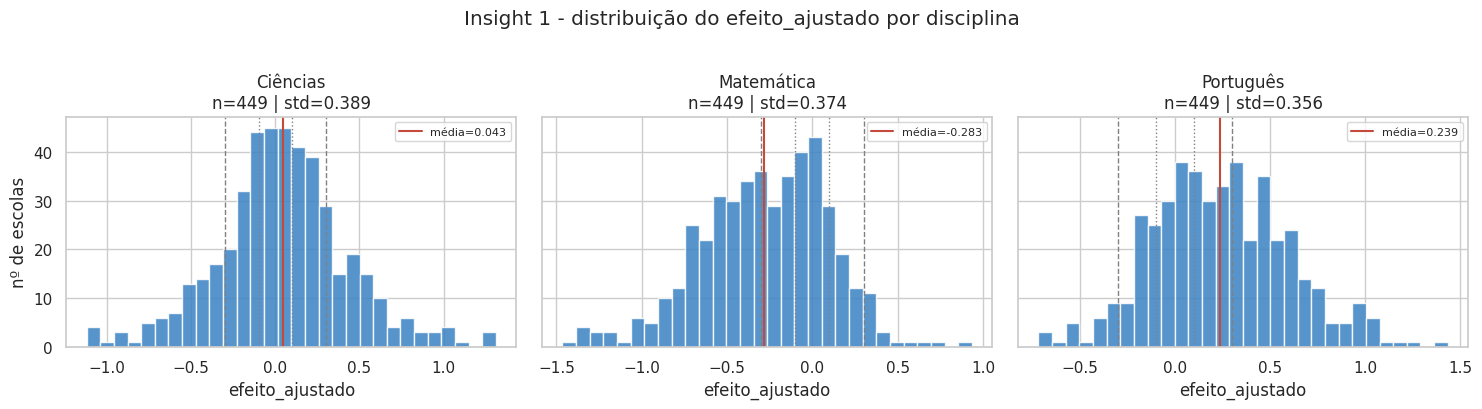


Estatísticas descritivas por disciplina:
            count   mean    std    min    25%    50%    75%    max
disciplina                                                        
Ciências    449.0  0.043  0.389 -1.123 -0.169  0.033  0.255  1.312
Matemática  449.0 -0.283  0.374 -1.464 -0.546 -0.261 -0.013  0.935
Português   449.0  0.239  0.356 -0.718 -0.009  0.225  0.463  1.436


In [4]:
REF_LINES = [(-0.30, "--"), (-0.10, ":"), (0.10, ":"), (0.30, "--")]
DESCRIBE_COLS = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]


def _plot_disciplina(ax, valores, disciplina):
    ax.hist(valores, bins=30, color="#3b82c4", alpha=0.85, edgecolor="white")
    for x, ls in REF_LINES:
        ax.axvline(x, linestyle=ls, color="gray", linewidth=1.0)
    ax.axvline(
        valores.mean(),
        linestyle="-",
        color="#c44a3b",
        linewidth=1.5,
        label=f"média={valores.mean():.3f}",
    )
    ax.set_title(f"{disciplina}\nn={len(valores)} | std={valores.std():.3f}")
    ax.set_xlabel("efeito_ajustado")
    ax.legend(loc="upper right", fontsize=8)


disciplinas = sorted(mart_diferencial["disciplina"].unique())
n_disc = len(disciplinas)

fig, axes = plt.subplots(1, n_disc, figsize=(5 * n_disc, 4), sharey=True)
if n_disc == 1:
    axes = [axes]

for ax, disc in zip(axes, disciplinas):
    valores = mart_diferencial.loc[
        mart_diferencial["disciplina"] == disc, "efeito_ajustado"
    ]
    _plot_disciplina(ax, valores, disc)

axes[0].set_ylabel("nº de escolas")
fig.suptitle("Insight 1 - distribuição do efeito_ajustado por disciplina", y=1.02)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "mart_01_distribuicao_efeito_ajustado.png",
    dpi=120,
    bbox_inches="tight",
)
plt.show()

print("\nEstatísticas descritivas por disciplina:")
print(
    mart_diferencial
    .groupby("disciplina")["efeito_ajustado"]
    .describe()[DESCRIBE_COLS]
    .round(3)
)


## 3. Insight 2 - Top-10 escolas por disciplina

Rankings `rank_na_disciplina <= 10`; coluna `confianca_estatistica` separa
sinal robusto (`significativo`) de amostra pequena (`inconclusivo`).

In [5]:
top10_por_disc = {}

TOP10_COLS = [
    "rank_na_disciplina",
    "escola_id",
    "n_obs",
    "efeito_ajustado",
    "ic_inferior",
    "ic_superior",
    "classificacao",
    "confianca_estatistica",
]

def _top10_disciplina(df, disciplina):
    return (
        df[df["disciplina"] == disciplina]
        .nsmallest(10, "rank_na_disciplina")[TOP10_COLS]
        .sort_values("rank_na_disciplina")
        .reset_index(drop=True)
    )

for disc in disciplinas:
    top = _top10_disciplina(mart_diferencial, disc)
    top10_por_disc[disc] = top
    print(f"\n=== Top-10 - {disc} ===")
    print(top.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


# Salvar tabelas como CSV para consumo opcional
for disc, df in top10_por_disc.items():
    df.to_csv(FIG_DIR / f"mart_02_top10_{disc.lower()}.csv", index=False)


=== Top-10 - Ciências ===
 rank_na_disciplina            escola_id  n_obs  efeito_ajustado  ic_inferior  ic_superior  classificacao confianca_estatistica
                  1  7302821136493122512    413            1.312        1.174        1.450 forte_positivo         significativo
                  2 -2927176673102842913    346            1.252        1.102        1.403 forte_positivo         significativo
                  3  5819877652477808414    127            1.231        0.988        1.474 forte_positivo         significativo
                  4 -8048261876750746043    351            1.137        0.988        1.286 forte_positivo         significativo
                  5 -4336750145478544435    299            1.039        0.878        1.200 forte_positivo         significativo
                  6 -6064222982637392725    637            1.025        0.914        1.136 forte_positivo         significativo
                  7  8154400948217762758    591            1.007        0.891

## 4. Insight 3 - Perfil disciplinar extremo (Matemática vs. Português)

Scatter mostrando escolas que destoam entre disciplinas. Pontos extremos
são pintados de vermelho. Pontos no canto superior-esquerdo (forte em Mat, fraca em Port) ou inferior-direito (inverso) sugerem perfis pedagógicos divergentes.

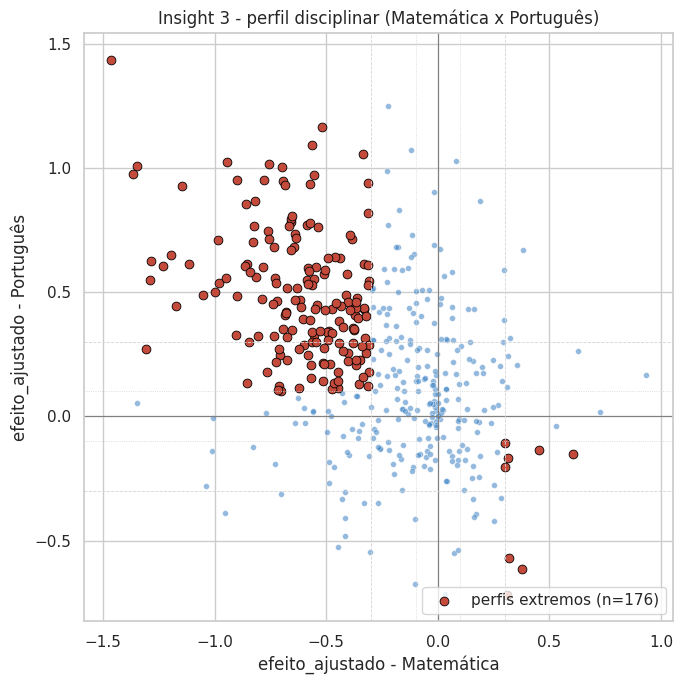


Escolas com perfil extremo: 176 de 449 (39.2%)


In [6]:
DISCIPLINAS_INSIGHT3 = ("Matemática", "Português")
REF_LINES = [(-0.30, "--"), (-0.10, ":"), (0.10, ":"), (0.30, "--")]


def _pivot_pares(df, disciplinas):
    return (
        df.pivot(index="escola_id", columns="disciplina", values="efeito_ajustado")
        [list(disciplinas)]
        .dropna()
    )


def _filtra_extremos(pivot, mat_col, port_col):
    forte_mat_fraco_port = (pivot[mat_col] >= 0.30) & (pivot[port_col] <= -0.10)
    fraco_mat_forte_port = (pivot[mat_col] <= -0.30) & (pivot[port_col] >= 0.10)
    return pivot[forte_mat_fraco_port | fraco_mat_forte_port]


def _desenha_grade(ax):
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    for x, ls in REF_LINES:
        ax.axvline(x, linestyle=ls, color="lightgray", linewidth=0.6)
        ax.axhline(x, linestyle=ls, color="lightgray", linewidth=0.6)


if not all(d in disciplinas for d in DISCIPLINAS_INSIGHT3):
    print("Matemática e/ou Português ausentes - pular insight 3.")
else:
    mat, port = DISCIPLINAS_INSIGHT3
    pivot = _pivot_pares(mart_diferencial, DISCIPLINAS_INSIGHT3)
    extremos = _filtra_extremos(pivot, mat, port)

    fig, ax = plt.subplots(figsize=(7, 7))
    _desenha_grade(ax)

    ax.scatter(
        pivot[mat], pivot[port],
        s=18, alpha=0.55, color="#3b82c4",
        edgecolor="white", linewidth=0.5,
    )
    ax.scatter(
        extremos[mat], extremos[port],
        s=40, color="#c44a3b", edgecolor="black", linewidth=0.6,
        label=f"perfis extremos (n={len(extremos)})",
    )

    ax.set_xlabel(f"efeito_ajustado - {mat}")
    ax.set_ylabel(f"efeito_ajustado - {port}")
    ax.set_title(f"Insight 3 - perfil disciplinar ({mat} x {port})")
    ax.legend(loc="lower right")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "mart_03_perfil_disciplinar.png", dpi=120, bbox_inches="tight")
    plt.show()

    pct_extremos = 100 * len(extremos) / len(pivot)
    print(
        f"\nEscolas com perfil extremo: {len(extremos)} de {len(pivot)} "
        f"({pct_extremos:.1f}%)"
    )


## 5. Insight 5 - Shrinkage (`efeito_bruto` x `efeito_ajustado`)

Scatter colorido por `n_obs`: escolas pequenas são puxadas para
zero (pontos próximos da horizontal), escolas grandes preservam o
`efeito_bruto` (pontos próximos da diagonal).

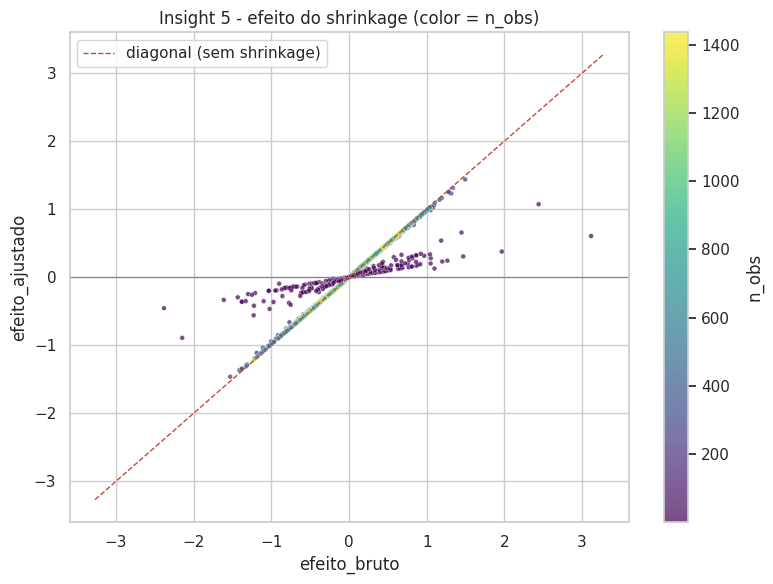

In [7]:
SCATTER_KW = dict(
    cmap="viridis",
    s=12,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.3,
)


def _limite_simetrico(serie, margem=1.05):
    return max(abs(serie.min()), abs(serie.max())) * margem


fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    mart_diferencial["efeito_bruto"],
    mart_diferencial["efeito_ajustado"],
    c=mart_diferencial["n_obs"],
    **SCATTER_KW,
)

lim = _limite_simetrico(mart_diferencial["efeito_bruto"])
ax.plot(
    [-lim, lim], [-lim, lim],
    color="#c44a3b", linewidth=1.0, linestyle="--",
    label="diagonal (sem shrinkage)",
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("efeito_bruto")
ax.set_ylabel("efeito_ajustado")
ax.set_title("Insight 5 - efeito do shrinkage (color = n_obs)")
ax.legend(loc="upper left")
plt.colorbar(sc, ax=ax, label="n_obs")

fig.tight_layout()
fig.savefig(FIG_DIR / "mart_04_shrinkage_em_acao.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Insight 6 - Mobilidade (`pct_obs_multi_escola`)

Boxplot da fração de `n_obs` cuja linha vem de aluno multi-escola.

/tmp/ipykernel_1012217/995760468.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


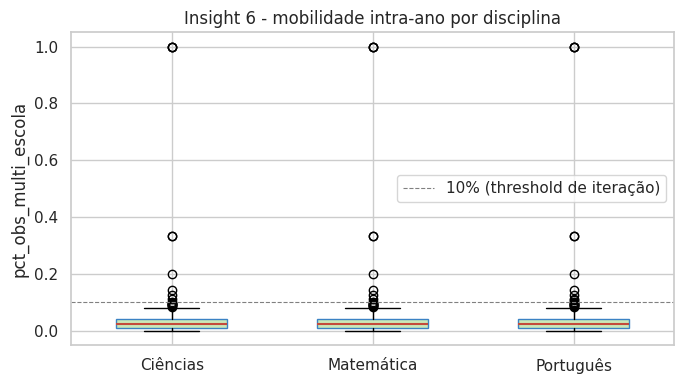


Mediana de pct_obs_multi_escola por disciplina:
            median   mean  max
disciplina                    
Ciências     0.025  0.035  1.0
Matemática   0.024  0.035  1.0
Português    0.025  0.035  1.0


In [8]:
THRESHOLD_MOBILIDADE = 0.10
BOX_FACE = "#cae8b8"
BOX_EDGE = "#3b82c4"
BOX_MEDIAN = {"color": "#c44a3b", "linewidth": 1.5}
AGG_MOBILIDADE = ["median", "mean", "max"]


def _valores_por_disciplina(df, disciplinas, coluna):
    return [df.loc[df["disciplina"] == d, coluna].values for d in disciplinas]


def _estiliza_caixas(bp, facecolor, edgecolor):
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_edgecolor(edgecolor)


fig, ax = plt.subplots(figsize=(7, 4))

dados_box = _valores_por_disciplina(mart_diferencial, disciplinas, "pct_obs_multi_escola")
bp = ax.boxplot(
    dados_box,
    labels=disciplinas,
    patch_artist=True,
    widths=0.55,
    medianprops=BOX_MEDIAN,
)
_estiliza_caixas(bp, BOX_FACE, BOX_EDGE)

ax.axhline(
    THRESHOLD_MOBILIDADE,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    label="10% (threshold de iteração)",
)
ax.set_ylabel("pct_obs_multi_escola")
ax.set_title("Insight 6 - mobilidade intra-ano por disciplina")
ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "mart_05_pct_obs_multi_escola.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nMediana de pct_obs_multi_escola por disciplina:")
print(
    mart_diferencial
    .groupby("disciplina")["pct_obs_multi_escola"]
    .agg(AGG_MOBILIDADE)
    .round(3)
)


## 7. Cruzamento `classificacao` x `confianca_estatistica`

Diagnóstico secundário: como os dois eixos (magnitude x robustez) se
distribuem? Espera-se que `forte_*` apareça com ambos os rótulos de
confiança - o filtro de robustez é responsabilidade do consumidor.

In [9]:
crosstab = pd.crosstab(
    mart_diferencial["classificacao"],
    mart_diferencial["confianca_estatistica"],
    margins=True,
    margins_name="total",
)
ordem_classif = ["forte_negativo", "moderado_negativo", "indistinguivel",
                 "moderado_positivo", "forte_positivo", "total"]
crosstab = crosstab.reindex([c for c in ordem_classif if c in crosstab.index])
print("\nCruzamento classificacao x confianca_estatistica:")
print(crosstab)


Cruzamento classificacao x confianca_estatistica:
confianca_estatistica  inconclusivo  significativo  total
classificacao                                            
forte_negativo                   12            293    305
moderado_negativo                82            126    208
indistinguivel                  296              1    297
moderado_positivo                73            166    239
forte_positivo                   12            286    298
total                           475            872   1347
